# Laboratorio 7: Spark MLlib

## Avance de análisis exploratorio y segmentación

**Integrantes:** Milton Polanco y Osman de León  
**Curso:** Data Science  
**Fecha:** 24 de septiembre de 2026

Este avance desarrolla las actividades 1 a 4 del laboratorio. Se preparan las bases de Personas de la ENEIC, se revisa la calidad de los datos, se describe la población analítica de 2025, se calculan correlaciones con Spark y se construye una segmentación con KMeans. El primer trimestre de 2026 queda preparado por separado para la evaluación final, pero no se utiliza en el ajuste del clustering.

Los resultados son no ponderados y describen los registros elegibles de la muestra. No constituyen estimaciones oficiales de la población de Guatemala.

## 1. Configuración y fuentes

Spark se usa para la preparación analítica, los cálculos y el clustering. Los archivos de Excel se leen individualmente con pandas porque Spark no incluye un lector nativo de Excel. Cada archivo se transforma de inmediato a un DataFrame de Spark con un esquema explícito y solo se conservan las columnas requeridas.

Fuente: Instituto Nacional de Estadística de Guatemala, Encuesta Nacional de Empleo e Ingresos Continua (ENEIC), https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/

**Entorno de ejecución:** usar el kernel `Python 3.11 (Lab 7 Spark 3.5)`. Antes de ejecutar todas las celdas, reiniciar el kernel si Jupyter o VS Code había seleccionado otro intérprete.

In [1]:
from pathlib import Path
import os
import sys

# Spark 3.5 se verificó con Python 3.11. El kernel global de Python 3.13
# provoca fallos de Py4J al iniciar los workers en Windows.
if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f"Kernel incorrecto: Python {sys.version_info.major}.{sys.version_info.minor}. "
        "Seleccione 'Python 3.11 (Lab 7 Spark 3.5)' y reinicie el kernel."
    )

import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Paleta discreta y legible para las gráficas del avance.
COLORS = {
    "blue": "#3366A3", "orange": "#E6862A", "green": "#3A8F6B",
    "red": "#B4494D", "purple": "#7656A5", "light_blue": "#9CC5E6",
}

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reporte" / "figuras"
for directory in (RAW_DIR, PROCESSED_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Configuración local para Windows. En Linux o Docker estas variables pueden omitirse.
java_candidates = [
    Path(r"C:\Program Files\Eclipse Adoptium\jdk-21.0.10.7-hotspot"),
    Path(r"C:\Program Files\Java\jdk-17"),
]
if os.name == "nt" and "JAVA_HOME" not in os.environ:
    for candidate in java_candidates:
        if candidate.exists():
            os.environ["JAVA_HOME"] = str(candidate)
            os.environ["PATH"] = str(candidate / "bin") + os.pathsep + os.environ["PATH"]
            break

hadoop_home = ROOT / ".tools" / "hadoop"
if os.name == "nt" and hadoop_home.exists():
    os.environ["HADOOP_HOME"] = str(hadoop_home)
    os.environ["PATH"] = str(hadoop_home / "bin") + os.pathsep + os.environ["PATH"]

# Los workers deben usar el mismo Python que ejecuta el notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession, functions as F, types as T, Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.storagelevel import StorageLevel

spark = (
    SparkSession.builder
    .master("local[4]")
    .appName("Lab7_ENEIC_Avance")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.default.parallelism", "4")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Python:", sys.version.split()[0])
print("Spark:", spark.version)
print("Directorio del proyecto:", ROOT)

Python: 3.11.15
Spark: 3.5.7
Directorio del proyecto: C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 7\Lab-7-Data-Science


In [2]:
FILES = [
    {
        "periodo": "2025T1", "anio": 2025, "trimestre": 1,
        "archivo": "personas_eneic_2025_t1.xlsx",
        "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx",
    },
    {
        "periodo": "2025T2", "anio": 2025, "trimestre": 2,
        "archivo": "personas_eneic_2025_t2.xlsx",
        "url": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx",
    },
    {
        "periodo": "2025T3", "anio": 2025, "trimestre": 3,
        "archivo": "personas_eneic_2025_t3.xlsx",
        "url": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    },
    {
        "periodo": "2025T4", "anio": 2025, "trimestre": 4,
        "archivo": "personas_eneic_2025_t4.xlsx",
        "url": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    },
    {
        "periodo": "2026T1", "anio": 2026, "trimestre": 1,
        "archivo": "personas_eneic_2026_t1.xlsx",
        "url": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
    },
]

for spec in FILES:
    path = RAW_DIR / spec["archivo"]
    spec["path"] = path
    if not path.exists():
        print("Descargando", spec["archivo"])
        request = urllib.request.Request(spec["url"], headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(path, "wb") as target:
            target.write(response.read())

pd.DataFrame(
    [{"periodo": x["periodo"], "archivo": x["archivo"], "tamano_MB": round(x["path"].stat().st_size / 1024**2, 1)} for x in FILES]
)

,periodo,archivo,tamano_MB
0,2025T1,personas_eneic_2025_t1.xlsx,45.5
1,2025T2,personas_eneic_2025_t2.xlsx,16.1
2,2025T3,personas_eneic_2025_t3.xlsx,45.4
3,2025T4,personas_eneic_2025_t4.xlsx,49.0
4,2026T1,personas_eneic_2026_t1.xlsx,43.9


## 2. Carga, armonización y calidad de datos

Se conserva el valor original de `TRIMESTRE`, pero el período calendario se asigna con base en el archivo de procedencia. Esto evita aplicar una resta automática que no resolvería los 175 registros del segundo archivo de 2025 cuyo valor original es 2. También se conserva `archivo_origen` para mantener la trazabilidad.

El cuarto trimestre de 2025 contiene 302 columnas, mientras que los otros archivos tienen 270. Además, algunas columnas cambiaron de posición. Por ese motivo no se deben apilar por posición: una unión posicional podría colocar valores de variables diferentes en una misma columna. La unión se realiza con `unionByName`.

In [3]:
RAW_COLS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A",
    "P05C16", "OCUPADOS", "P05D01",
]

raw_schema = T.StructType([T.StructField(name, T.StringType(), True) for name in RAW_COLS])

def canonical_text(value):
    if pd.isna(value):
        return None
    if isinstance(value, (float, np.floating)) and np.isfinite(value) and float(value).is_integer():
        return str(int(value))
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    text = str(value).strip()
    return text if text else None

def read_person_file(spec):
    pdf = pd.read_excel(spec["path"], usecols=lambda c: c in RAW_COLS, engine="openpyxl")
    missing = sorted(set(RAW_COLS) - set(pdf.columns))
    if missing:
        raise ValueError(f"Faltan columnas en {spec['archivo']}: {missing}")
    pdf = pdf[RAW_COLS].map(canonical_text)
    sdf = spark.createDataFrame(pdf, schema=raw_schema)
    return (
        sdf
        .withColumn("periodo_archivo", F.lit(spec["periodo"]))
        .withColumn("anio_archivo", F.lit(spec["anio"]).cast("int"))
        .withColumn("trimestre_calendario", F.lit(spec["trimestre"]).cast("int"))
        .withColumn("archivo_origen", F.lit(spec["archivo"]))
    ), len(pdf)

frames = {}
source_counts = []
for spec in FILES:
    sdf, n_rows = read_person_file(spec)
    frames[spec["periodo"]] = sdf
    source_counts.append({"periodo_archivo": spec["periodo"], "registros_originales": n_rows})
    print(spec["periodo"], f"{n_rows:,}", "registros")

raw_2025 = frames["2025T1"]
for period in ["2025T2", "2025T3", "2025T4"]:
    raw_2025 = raw_2025.unionByName(frames[period], allowMissingColumns=True)
raw_2025 = raw_2025.persist(StorageLevel.MEMORY_AND_DISK)
raw_2026 = frames["2026T1"].persist(StorageLevel.MEMORY_AND_DISK)

print("Total 2025:", f"{raw_2025.count():,}")
print("Total 2026T1:", f"{raw_2026.count():,}")

2025T1 51,588 registros


2025T2 51,167 registros


2025T3 51,583 registros


2025T4 49,338 registros


2026T1 49,843 registros


Total 2025: 203,676


Total 2026T1: 49,843


### Valores originales de TRIMESTRE

La revisión por archivo conserva los valores originales y asigna el calendario por procedencia:

| Archivo | Valor original de `TRIMESTRE` |
|---|---:|
| 2025T1 | 2 |
| 2025T2 | 3 y 2 en 175 registros |
| 2025T3 | 4 |
| 2025T4 | 5 |
| 2026T1 | 6 |

El valor 2 en parte de 2025T2 confirma que restar uno a `TRIMESTRE` no produce una identificación calendario válida para todos los registros.

In [4]:
def clean_number(column_name):
    return F.regexp_replace(F.trim(F.col(column_name)), ",", "").cast("double")

def clean_code(column_name):
    return F.regexp_replace(F.trim(F.col(column_name)), r"\.0$", "")

def is_finite(column_name):
    c = F.col(column_name)
    return c.isNotNull() & (~F.isnan(c)) & (F.abs(c) != F.lit(float("inf")))

education_labels = {
    "0": "Ninguno", "1": "Preprimaria", "2": "Primaria", "3": "Básico",
    "4": "Diversificado", "5": "Superior", "6": "Maestría", "7": "Doctorado",
}
occupation_labels = {
    "1": "Empleado de gobierno", "2": "Empleado de empresa privada",
    "3": "Jornalero o peón", "4": "Servicio doméstico",
}
domain_labels = {"1": "Urbano metropolitano", "2": "Resto urbano", "3": "Rural nacional"}

def mapping_expr(mapping):
    pairs = []
    for key, value in mapping.items():
        pairs.extend([F.lit(key), F.lit(value)])
    return F.create_map(*pairs)

def type_and_label(df):
    typed = (
        df
        .withColumn("edad", clean_number("P02A03"))
        .withColumn("antiguedad_anios", clean_number("P05C07A"))
        .withColumn("antiguedad_meses", clean_number("P05C07B"))
        .withColumn("horas_semanales", clean_number("P05H01A"))
        .withColumn("salario_mensual", clean_number("P05D01"))
        .withColumn("nivel_educativo_codigo", clean_code("P03A03A"))
        .withColumn("categoria_ocupacional_codigo", clean_code("P05C16"))
        .withColumn("dominio_codigo", clean_code("DOMINIO"))
        .withColumn("ocupado_codigo", clean_code("OCUPADOS"))
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0))
        .withColumn(
            "nivel_educativo",
            F.coalesce(mapping_expr(education_labels)[F.col("nivel_educativo_codigo")], F.lit("DESCONOCIDO")),
        )
        .withColumn(
            "categoria_ocupacional",
            F.coalesce(mapping_expr(occupation_labels)[F.col("categoria_ocupacional_codigo")], F.lit("DESCONOCIDO")),
        )
        .withColumn(
            "dominio",
            F.coalesce(mapping_expr(domain_labels)[F.col("dominio_codigo")], F.lit("DESCONOCIDO")),
        )
    )
    return typed

typed_2025 = type_and_label(raw_2025).persist(StorageLevel.MEMORY_AND_DISK)
typed_2026 = type_and_label(raw_2026).persist(StorageLevel.MEMORY_AND_DISK)

selected_view = [
    "periodo_archivo", "ANIO", "TRIMESTRE", "anio_archivo", "trimestre_calendario",
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "edad", "antiguedad_anios",
    "antiguedad_meses", "antiguedad", "horas_semanales", "nivel_educativo",
    "categoria_ocupacional", "dominio", "ocupado_codigo", "salario_mensual",
]
typed_2025.select(*selected_view).printSchema()
typed_2025.select(*selected_view).show(5, truncate=False)

root
 |-- periodo_archivo: string (nullable = false)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = false)
 |-- categoria_ocupacional: string (nullable = false)
 |-- dominio: string (nullable = false)
 |-- ocupado_codigo: string (nullable = true)
 |-- salario_mensual: double (nullable = true)



+---------------+----+---------+------------+--------------------+---------+-----------+------+----+----------------+----------------+----------+---------------+---------------+---------------------+------------+--------------+---------------+
|periodo_archivo|ANIO|TRIMESTRE|anio_archivo|trimestre_calendario|NUM_HOGAR|NUM_PERSONA|FACTOR|edad|antiguedad_anios|antiguedad_meses|antiguedad|horas_semanales|nivel_educativo|categoria_ocupacional|dominio     |ocupado_codigo|salario_mensual|
+---------------+----+---------+------------+--------------------+---------+-----------+------+----+----------------+----------------+----------+---------------+---------------+---------------------+------------+--------------+---------------+
|2025T1         |2025|2        |2025        |1                   |13796    |3          |338   |14.0|NULL            |NULL            |NULL      |NULL           |Básico         |DESCONOCIDO          |Resto urbano|NULL          |NULL           |
|2025T1         |2025|2 

### Faltantes antes de los filtros

Un dato puede estar vacío porque la pregunta no correspondía al flujo de la entrevista, por ejemplo, preguntas laborales para una persona no ocupada. Ese caso es distinto de una respuesta no registrada cuando la pregunta sí correspondía. La celda vacía no permite distinguir por sí sola ambos motivos; para interpretarla se necesita el flujo de la boleta y las variables de control. Por eso se reportan los faltantes y luego se aplican los filtros en un orden fijo.

In [5]:
missing_vars = [
    "P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A",
    "P05C16", "DOMINIO", "OCUPADOS", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "ANIO", "TRIMESTRE",
]
total_before = raw_2025.count()
missing_exprs = [
    F.sum(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), 1).otherwise(0)).alias(c)
    for c in missing_vars
]
missing_row = raw_2025.agg(*missing_exprs).first().asDict()
missing_table = pd.DataFrame([
    {
        "variable": c,
        "faltantes": int(missing_row[c]),
        "porcentaje": 100.0 * int(missing_row[c]) / total_before,
    }
    for c in missing_vars
]).sort_values(["porcentaje", "variable"], ascending=[False, True])
missing_table.style.format({"faltantes": "{:,.0f}", "porcentaje": "{:.2f}%"})

,variable,faltantes,porcentaje
0,P05D01,"150,651",73.97%
8,OCUPADOS,"115,454",56.69%
2,P05C07A,"115,454",56.69%
3,P05C07B,"115,454",56.69%
6,P05C16,"115,454",56.69%
4,P05H01A,"115,454",56.69%
5,P03A03A,"26,344",12.93%
12,ANIO,0,0.00%
7,DOMINIO,0,0.00%
11,FACTOR,0,0.00%


**Lectura de faltantes.** Antes de filtrar, `P05D01` está vacío en 73.97% de los registros. `OCUPADOS`, categoría ocupacional, antigüedad y horas presentan 56.69% de faltantes, y el nivel educativo 12.93%. La coincidencia entre varias preguntas laborales es consistente con saltos del cuestionario: no toda ausencia debe interpretarse como un error de captura.

### Aplicación secuencial de filtros

El orden se mantiene igual para 2025 y 2026. Cada fila se asigna al primer criterio que no cumple, por lo que las exclusiones de la tabla no se traslapan. No se imputan salarios ni se eliminan valores extremos por percentiles.

In [6]:
FILTERS = [
    ("Edad numérica, finita y mayor o igual a 15", is_finite("edad") & (F.col("edad") >= 15)),
    ("Persona ocupada (OCUPADOS = 1)", F.col("ocupado_codigo") == "1"),
    ("Categoría asalariada (P05C16 entre 1 y 4)", F.col("categoria_ocupacional_codigo").isin("1", "2", "3", "4")),
    ("Salario numérico, finito y positivo", is_finite("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("Años de antigüedad numéricos, finitos y no negativos", is_finite("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    (
        "Meses de antigüedad enteros entre 0 y 11",
        is_finite("antiguedad_meses")
        & (F.col("antiguedad_meses") >= 0)
        & (F.col("antiguedad_meses") <= 11)
        & (F.col("antiguedad_meses") == F.floor(F.col("antiguedad_meses"))),
    ),
    ("Antigüedad calculada menor o igual a la edad", is_finite("antiguedad") & (F.col("antiguedad") <= F.col("edad"))),
    (
        "Horas habituales numéricas, finitas y entre 1 y 168",
        is_finite("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168),
    ),
]

def apply_filters(df, label):
    current = df
    audit = []
    for order, (criterion, condition) in enumerate(FILTERS, start=1):
        before = current.count()
        next_df = current.filter(condition).persist(StorageLevel.MEMORY_AND_DISK)
        after = next_df.count()
        audit.append({
            "conjunto": label,
            "orden": order,
            "criterio": criterion,
            "antes": before,
            "excluidos": before - after,
            "despues": after,
        })
        if current is not df:
            current.unpersist()
        current = next_df
    return current, pd.DataFrame(audit)

filtered_2025, audit_2025 = apply_filters(typed_2025, "2025")
filtered_2026, audit_2026 = apply_filters(typed_2026, "2026T1")

display(audit_2025.style.format({"antes": "{:,.0f}", "excluidos": "{:,.0f}", "despues": "{:,.0f}"}))
display(audit_2026.style.format({"antes": "{:,.0f}", "excluidos": "{:,.0f}", "despues": "{:,.0f}"}))

,conjunto,orden,criterio,antes,excluidos,despues
0,2025,1,"Edad numérica, finita y mayor o igual a 15","203,676","62,886","140,790"
1,2025,2,Persona ocupada (OCUPADOS = 1),"140,790","52,568","88,222"
2,2025,3,Categoría asalariada (P05C16 entre 1 y 4),"88,222","35,197","53,025"
3,2025,4,"Salario numérico, finito y positivo","53,025",0,"53,025"
4,2025,5,"Años de antigüedad numéricos, finitos y no negativos","53,025",0,"53,025"
5,2025,6,Meses de antigüedad enteros entre 0 y 11,"53,025",0,"53,025"
6,2025,7,Antigüedad calculada menor o igual a la edad,"53,025",0,"53,025"
7,2025,8,"Horas habituales numéricas, finitas y entre 1 y 168","53,025",0,"53,025"


,conjunto,orden,criterio,antes,excluidos,despues
0,2026T1,1,"Edad numérica, finita y mayor o igual a 15","49,843","14,803","35,040"
1,2026T1,2,Persona ocupada (OCUPADOS = 1),"35,040","13,306","21,734"
2,2026T1,3,Categoría asalariada (P05C16 entre 1 y 4),"21,734","8,476","13,258"
3,2026T1,4,"Salario numérico, finito y positivo","13,258",0,"13,258"
4,2026T1,5,"Años de antigüedad numéricos, finitos y no negativos","13,258",0,"13,258"
5,2026T1,6,Meses de antigüedad enteros entre 0 y 11,"13,258",0,"13,258"
6,2026T1,7,Antigüedad calculada menor o igual a la edad,"13,258",0,"13,258"
7,2026T1,8,"Horas habituales numéricas, finitas y entre 1 y 168","13,258",0,"13,258"


**Resultado de los filtros.** Los cuatro archivos de 2025 reúnen 203,676 registros. El criterio de edad deja 140,790; el filtro de ocupados deja 88,222; y la selección de asalariados deja 53,025. En ese subconjunto no se excluyeron filas adicionales por salario, antigüedad u horas, porque todas cumplieron los rangos establecidos. Para 2026T1 quedan 13,258 registros elegibles.

In [7]:
FINAL_COLS = [
    "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
    "horas_semanales", "nivel_educativo_codigo", "nivel_educativo",
    "categoria_ocupacional_codigo", "categoria_ocupacional",
    "dominio_codigo", "dominio", "ocupado_codigo", "salario_mensual",
]
prepared_2025 = filtered_2025.select(*FINAL_COLS).persist(StorageLevel.MEMORY_AND_DISK)
prepared_2026 = filtered_2026.select(*FINAL_COLS).persist(StorageLevel.MEMORY_AND_DISK)

counts_after = {
    row["periodo_archivo"]: row["count"]
    for row in prepared_2025.groupBy("periodo_archivo").count().collect()
}
counts_after.update({"2026T1": prepared_2026.count()})
counts_table = pd.DataFrame(source_counts)
counts_table["registros_analiticos"] = counts_table["periodo_archivo"].map(counts_after)
counts_table["porcentaje_conservado"] = 100 * counts_table["registros_analiticos"] / counts_table["registros_originales"]
counts_table.style.format({
    "registros_originales": "{:,.0f}",
    "registros_analiticos": "{:,.0f}",
    "porcentaje_conservado": "{:.2f}%",
})

,periodo_archivo,registros_originales,registros_analiticos,porcentaje_conservado
0,2025T1,"51,588","13,419",26.01%
1,2025T2,"51,167","13,492",26.37%
2,2025T3,"51,583","13,450",26.07%
3,2025T4,"49,338","12,664",25.67%
4,2026T1,"49,843","13,258",26.60%


**Registros por período.** La población analítica contiene 13,419 registros en 2025T1, 13,492 en 2025T2, 13,450 en 2025T3 y 12,664 en 2025T4. La proporción conservada se mantiene cerca de 26% en los cinco archivos, lo cual indica que el mismo procedimiento se aplicó de forma consistente.

### Unicidad de las claves

La combinación `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA` identifica una observación dentro de cada corte. Si una misma persona aparece en dos períodos, no se elimina: son observaciones longitudinales distintas y pueden reflejar cambios reales en empleo, jornada o salario. Se investigan las claves repetidas dentro del mismo período y se distingue entre filas exactas y registros en conflicto, sin usar `dropDuplicates()` para ocultarlas.

In [8]:
key_cols = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
duplicate_keys = raw_2025.groupBy(*key_cols).count().filter(F.col("count") > 1)
duplicate_key_count = duplicate_keys.count()

hash_cols = [c for c in raw_2025.columns if c not in key_cols]
row_hash = F.sha2(F.concat_ws("||", *[F.coalesce(F.col(c), F.lit("<NULL>")) for c in hash_cols]), 256)
duplicate_detail = (
    raw_2025.withColumn("row_hash", row_hash)
    .join(duplicate_keys.select(*key_cols), on=key_cols, how="inner")
    .groupBy(*key_cols)
    .agg(F.count("*").alias("filas"), F.countDistinct("row_hash").alias("versiones_distintas"))
)
exact_duplicate_keys = duplicate_detail.filter(F.col("versiones_distintas") == 1).count()
conflicting_duplicate_keys = duplicate_detail.filter(F.col("versiones_distintas") > 1).count()

uniqueness_table = pd.DataFrame([{
    "claves_repetidas": duplicate_key_count,
    "repeticiones_exactas": exact_duplicate_keys,
    "claves_con_conflicto": conflicting_duplicate_keys,
}])
display(uniqueness_table)
if duplicate_key_count:
    duplicate_detail.orderBy(F.desc("versiones_distintas"), F.desc("filas")).show(20, truncate=False)

,claves_repetidas,repeticiones_exactas,claves_con_conflicto
0,0,0,0


No se encontraron claves repetidas dentro de un mismo período. Por tanto, no fue necesario resolver repeticiones exactas ni conflictos entre registros, y no se eliminó ninguna fila por duplicidad.

In [9]:
# Los archivos Parquet permiten retomar el análisis sin volver a leer Excel.
path_2025 = str((PROCESSED_DIR / "eneic_personas_2025_preparado.parquet").resolve())
path_2026 = str((PROCESSED_DIR / "eneic_personas_2026_t1_preparado.parquet").resolve())
prepared_2025.write.mode("overwrite").parquet(path_2025)
prepared_2026.write.mode("overwrite").parquet(path_2026)
print("Guardado:", path_2025)
print("Guardado:", path_2026)

Guardado: C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 7\Lab-7-Data-Science\data\processed\eneic_personas_2025_preparado.parquet
Guardado: C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 7\Lab-7-Data-Science\data\processed\eneic_personas_2026_t1_preparado.parquet


### Alcance de la población analítica

El número de registros filtrados no representa a todos los trabajadores del país. La base contiene personas incluidas en el diseño muestral y el análisis se limita a ocupados asalariados de 15 años o más con salario positivo y variables numéricas válidas. Además, los resultados de este avance no usan el factor de expansión. `FACTOR` se conserva porque sería necesario, junto con el diseño de la encuesta, para producir estimaciones poblacionales; aquí las métricas y los clusters describen únicamente los registros analizados.

## 3. Estadística descriptiva de 2025

Las estadísticas se calculan en Spark sobre todos los registros elegibles de 2025. Solo las tablas agregadas y una muestra fija de 10,000 filas se transfieren a pandas para elaborar las figuras.

In [10]:
numeric_vars = {
    "salario_mensual": "Salario mensual (Q)",
    "edad": "Edad (años)",
    "antiguedad": "Antigüedad (años)",
    "horas_semanales": "Horas habituales por semana",
}

stats_rows = []
for column, label in numeric_vars.items():
    result = prepared_2025.agg(
        F.count(column).alias("n"),
        F.avg(column).alias("media"),
        F.expr(f"percentile_approx({column}, 0.5, 10000)").alias("mediana"),
        F.stddev_samp(column).alias("desviacion_estandar"),
        F.min(column).alias("minimo"),
        F.max(column).alias("maximo"),
        F.expr(f"percentile_approx({column}, 0.25, 10000)").alias("p25"),
        F.expr(f"percentile_approx({column}, 0.75, 10000)").alias("p75"),
        F.expr(f"percentile_approx({column}, 0.95, 10000)").alias("p95"),
    ).first().asDict()
    result["variable"] = label
    stats_rows.append(result)

stats_table = pd.DataFrame(stats_rows)[
    ["variable", "n", "media", "mediana", "desviacion_estandar", "minimo", "maximo", "p25", "p75", "p95"]
]
stats_table.style.format({c: "{:,.2f}" for c in stats_table.columns if c != "variable"})

,variable,n,media,mediana,desviacion_estandar,minimo,maximo,p25,p75,p95
0,Salario mensual (Q),"53,025.00","3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00"
1,Edad (años),"53,025.00",35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00
2,Antigüedad (años),"53,025.00",5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00
3,Horas habituales por semana,"53,025.00",46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00


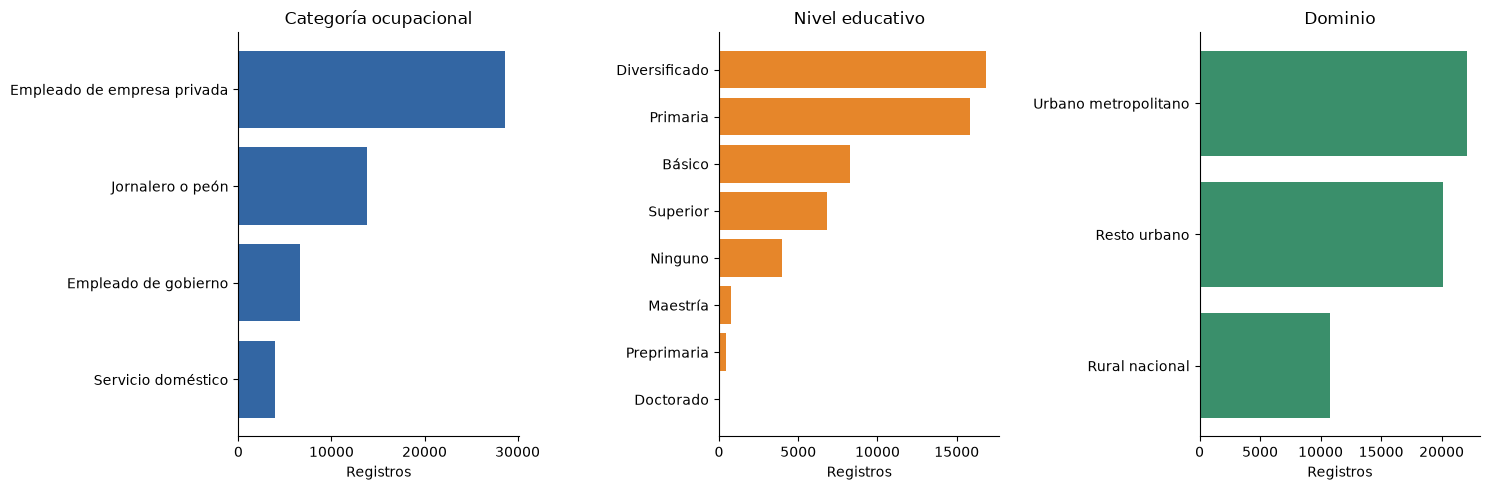

In [11]:
def grouped_count(column):
    total = prepared_2025.count()
    return (
        prepared_2025.groupBy(column).count()
        .withColumn("porcentaje", 100 * F.col("count") / F.lit(total))
        .orderBy(F.desc("count"))
        .toPandas()
    )

occupation_dist = grouped_count("categoria_ocupacional")
education_dist = grouped_count("nivel_educativo")
domain_dist = grouped_count("dominio")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, table, column, title, color in [
    (axes[0], occupation_dist, "categoria_ocupacional", "Categoría ocupacional", COLORS["blue"]),
    (axes[1], education_dist, "nivel_educativo", "Nivel educativo", COLORS["orange"]),
    (axes[2], domain_dist, "dominio", "Dominio", COLORS["green"]),
]:
    plot_data = table.sort_values("count")
    ax.barh(plot_data[column], plot_data["count"], color=color)
    ax.set_title(title)
    ax.set_xlabel("Registros")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "distribucion_categorias.png", dpi=180, bbox_inches="tight")
plt.show()

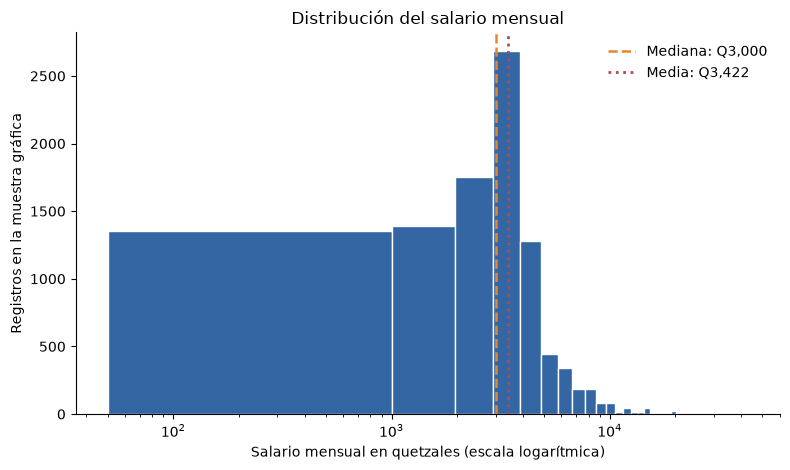

Diferencia entre media y mediana: Q421.68


In [12]:
plot_sample = (
    prepared_2025.orderBy(F.rand(seed=20260924))
    .limit(10000)
    .select("salario_mensual", "edad", "antiguedad", "horas_semanales")
    .toPandas()
)

wage_mean = stats_table.loc[stats_table["variable"] == "Salario mensual (Q)", "media"].iloc[0]
wage_median = stats_table.loc[stats_table["variable"] == "Salario mensual (Q)", "mediana"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(plot_sample["salario_mensual"], bins=45, color=COLORS["blue"], edgecolor="white")
ax.set_xscale("log")
ax.axvline(wage_median, color=COLORS["orange"], linestyle="--", linewidth=1.8, label=f"Mediana: Q{wage_median:,.0f}")
ax.axvline(wage_mean, color=COLORS["red"], linestyle=":", linewidth=2.0, label=f"Media: Q{wage_mean:,.0f}")
ax.set_title("Distribución del salario mensual")
ax.set_xlabel("Salario mensual en quetzales (escala logarítmica)")
ax.set_ylabel("Registros en la muestra gráfica")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "distribucion_salario.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Diferencia entre media y mediana: Q{wage_mean - wage_median:,.2f}")

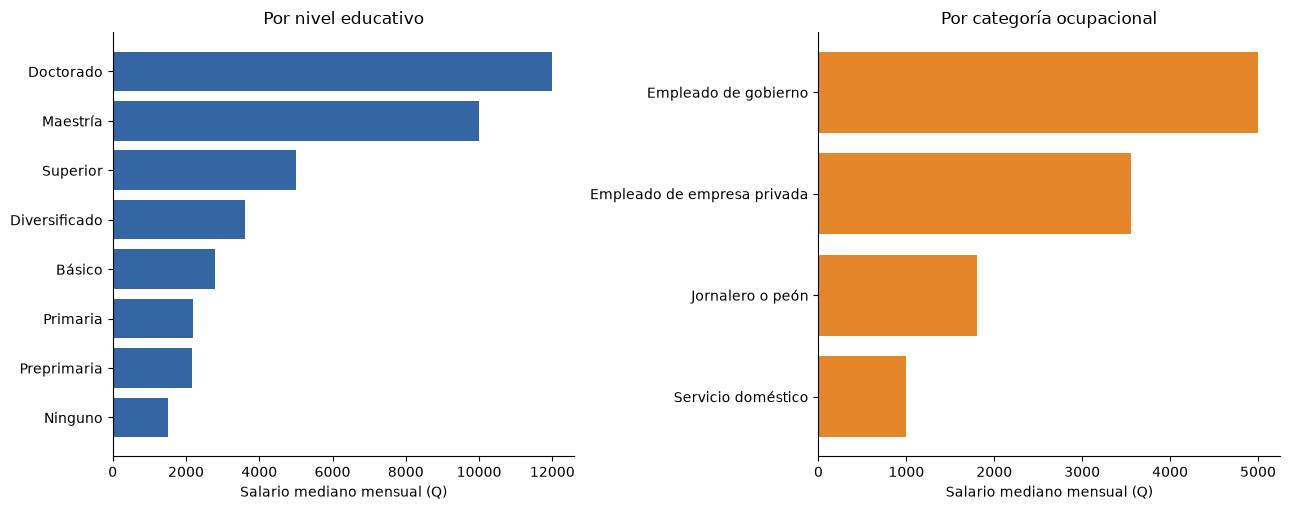

,nivel_educativo,n,salario_mediano
0,Doctorado,60,"Q12,000"
1,Maestría,771,"Q10,000"
2,Superior,"6,818","Q5,000"
3,Diversificado,"16,851","Q3,600"
4,Básico,"8,249","Q2,800"
5,Primaria,"15,822","Q2,200"
6,Preprimaria,459,"Q2,160"
7,Ninguno,"3,995","Q1,500"


,categoria_ocupacional,n,salario_mediano
0,Empleado de gobierno,"6,575","Q5,000"
1,Empleado de empresa privada,"28,702","Q3,560"
2,Jornalero o peón,"13,842","Q1,800"
3,Servicio doméstico,"3,906","Q1,000"


In [13]:
median_by_education = (
    prepared_2025.groupBy("nivel_educativo")
    .agg(F.count("*").alias("n"), F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"))
    .orderBy(F.desc("salario_mediano"))
    .toPandas()
)
median_by_occupation = (
    prepared_2025.groupBy("categoria_ocupacional")
    .agg(F.count("*").alias("n"), F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"))
    .orderBy(F.desc("salario_mediano"))
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, table, column, title, color in [
    (axes[0], median_by_education, "nivel_educativo", "Por nivel educativo", COLORS["blue"]),
    (axes[1], median_by_occupation, "categoria_ocupacional", "Por categoría ocupacional", COLORS["orange"]),
]:
    plot_data = table.sort_values("salario_mediano")
    ax.barh(plot_data[column], plot_data["salario_mediano"], color=color)
    ax.set_title(title)
    ax.set_xlabel("Salario mediano mensual (Q)")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "salario_mediano_grupos.png", dpi=180, bbox_inches="tight")
plt.show()

display(median_by_education.style.format({"n": "{:,.0f}", "salario_mediano": "Q{:,.0f}"}))
display(median_by_occupation.style.format({"n": "{:,.0f}", "salario_mediano": "Q{:,.0f}"}))

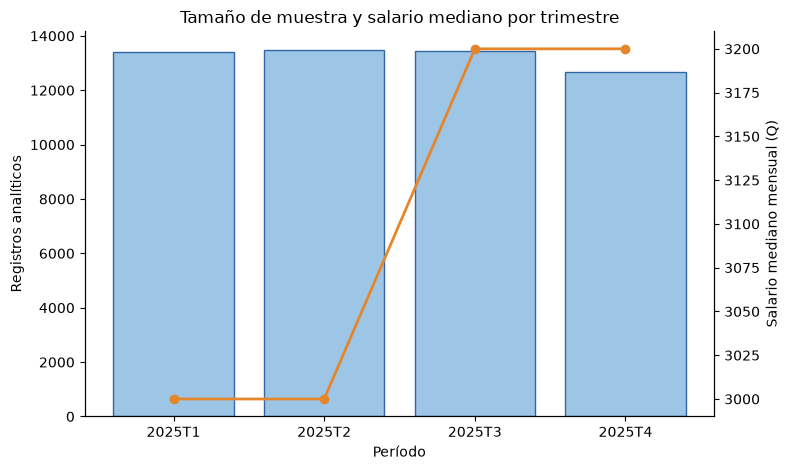

,periodo_archivo,n,salario_mediano
0,2025T1,"13,419","Q3,000"
1,2025T2,"13,492","Q3,000"
2,2025T3,"13,450","Q3,200"
3,2025T4,"12,664","Q3,200"


In [14]:
quarter_table = (
    prepared_2025.groupBy("periodo_archivo")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"),
    )
    .orderBy("periodo_archivo")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.bar(quarter_table["periodo_archivo"], quarter_table["n"], color=COLORS["light_blue"], edgecolor=COLORS["blue"])
ax1.set_ylabel("Registros analíticos")
ax1.set_xlabel("Período")
ax1.spines["top"].set_visible(False)
ax2 = ax1.twinx()
ax2.plot(quarter_table["periodo_archivo"], quarter_table["salario_mediano"], color=COLORS["orange"], marker="o", linewidth=2.0)
ax2.set_ylabel("Salario mediano mensual (Q)")
ax2.spines["top"].set_visible(False)
ax1.set_title("Tamaño de muestra y salario mediano por trimestre")
fig.tight_layout()
fig.savefig(FIG_DIR / "muestra_salario_trimestre.png", dpi=180, bbox_inches="tight")
plt.show()

quarter_table.style.format({"n": "{:,.0f}", "salario_mediano": "Q{:,.0f}"})

### Interpretación de la distribución y los grupos

La población analítica de 2025 contiene 53,025 observaciones. El salario medio es Q3,421.68 y la mediana Q3,000.00; la diferencia de Q421.68, el máximo de Q99,000 y el percentil 95 de Q8,000 muestran una distribución sesgada a la derecha. Por eso la escala logarítmica permite observar mejor la parte central sin modificar el salario usado en el análisis.

El empleo privado reúne 54.13% de los registros, seguido por jornaleros o peones con 26.10%. Los niveles educativos más frecuentes son diversificado (31.78%) y primaria (29.84%). Por dominio, 41.63% corresponde al urbano metropolitano, 37.99% al resto urbano y 20.38% al rural nacional.

El salario mediano aumenta de Q1,500 entre quienes no tienen nivel aprobado a Q5,000 en educación superior y Q10,000 en maestría. El doctorado alcanza Q12,000, pero solo contiene 60 observaciones y debe interpretarse con cautela. Por categoría ocupacional, las medianas son Q5,000 en gobierno, Q3,560 en empresa privada, Q1,800 entre jornaleros y Q1,000 en servicio doméstico.

El tamaño analítico es estable durante los tres primeros trimestres y baja a 12,664 en 2025T4. La mediana salarial pasa de Q3,000 en los dos primeros cortes a Q3,200 en los dos últimos. Esta comparación es descriptiva y no ajusta por cambios en la composición de la muestra.

## 4. Relaciones entre variables numéricas

La matriz usa la correlación de Pearson calculada con `VectorAssembler` y `Correlation.corr()` sobre todos los registros elegibles de 2025. Una correlación resume asociación lineal; no demuestra causalidad.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


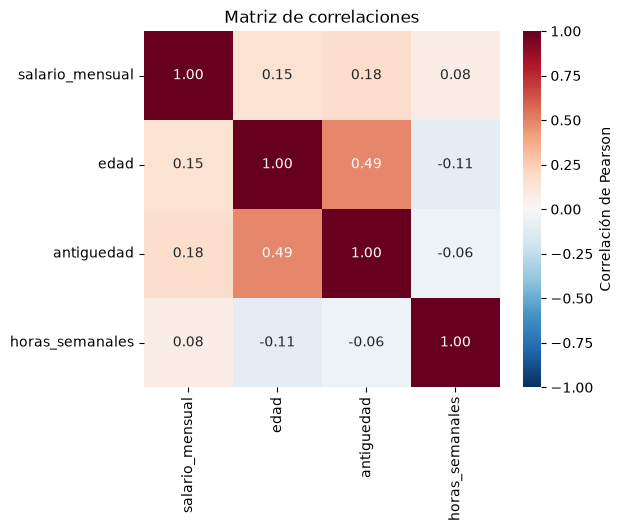

In [15]:
corr_columns = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
corr_assembler = VectorAssembler(inputCols=corr_columns, outputCol="corr_features")
corr_vector = corr_assembler.transform(prepared_2025).select("corr_features")
corr_matrix = Correlation.corr(corr_vector, "corr_features", "pearson").head()[0].toArray()
corr_table = pd.DataFrame(corr_matrix, index=corr_columns, columns=corr_columns)
display(corr_table.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(6.4, 5.3))
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"label": "Correlación de Pearson"}, ax=ax)
ax.set_title("Matriz de correlaciones")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlaciones.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretación de las correlaciones

La antigüedad presenta la mayor asociación lineal con el salario, aunque es débil $r = 0.180$. Le siguen la edad $r = 0.147$ y las horas semanales $r = 0.076$. Ninguna de estas variables, por sí sola, explica una parte grande de la variación salarial. Edad y antigüedad tienen una relación positiva moderada $r = 0.487$, coherente con que las personas de mayor edad han tenido más tiempo para acumular permanencia laboral.

## 5. Segmentación de perfiles con KMeans

Se comparan dos especificaciones. La primera usa edad, antigüedad y horas habituales; la segunda agrega salario mensual. Todas las variables se estandarizan con media cero y desviación estándar uno. Para cada especificación se ajustan modelos con $K = 2, 3, 4, 5$ y semilla fija.

El criterio acordado es seleccionar la mayor silueta entre soluciones en las que el cluster más pequeño tenga al menos 5% de los registros. Esta restricción evita elegir una solución que se limite a aislar unos pocos salarios extremos. Si dos alternativas tienen resultados cercanos, se prefiere la de menos variables y menor número de clusters por facilidad de interpretación.

In [16]:
CLUSTER_SPECS = {
    "Sin salario": ["edad", "antiguedad", "horas_semanales"],
    "Con salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
}

cluster_runs = []
cluster_objects = {}
total_cluster_rows = prepared_2025.count()

for spec_name, feature_cols in CLUSTER_SPECS.items():
    raw_col = "features_raw_" + spec_name.lower().replace(" ", "_")
    scaled_col = "features_" + spec_name.lower().replace(" ", "_")
    assembler = VectorAssembler(inputCols=feature_cols, outputCol=raw_col)
    assembled = assembler.transform(prepared_2025)
    scaler = StandardScaler(inputCol=raw_col, outputCol=scaled_col, withMean=True, withStd=True)
    scaler_model = scaler.fit(assembled)
    scaled = scaler_model.transform(assembled).persist(StorageLevel.MEMORY_AND_DISK)
    evaluator = ClusteringEvaluator(featuresCol=scaled_col, predictionCol="prediction", metricName="silhouette", distanceMeasure="squaredEuclidean")

    for k in [2, 3, 4, 5]:
        model = KMeans(
            featuresCol=scaled_col,
            predictionCol="prediction",
            k=k,
            seed=20260924,
            maxIter=100,
            tol=1e-4,
            initMode="k-means||",
        ).fit(scaled)
        predictions = model.transform(scaled).persist(StorageLevel.MEMORY_AND_DISK)
        silhouette = evaluator.evaluate(predictions)
        cluster_counts = predictions.groupBy("prediction").count().collect()
        min_share = min(row["count"] for row in cluster_counts) / total_cluster_rows
        cluster_runs.append({
            "especificacion": spec_name,
            "variables": ", ".join(feature_cols),
            "k": k,
            "silueta": silhouette,
            "participacion_minima": min_share,
            "costo_entrenamiento": float(model.summary.trainingCost),
        })
        cluster_objects[(spec_name, k)] = (model, scaler_model, assembler, scaled_col, predictions)

cluster_evaluation = pd.DataFrame(cluster_runs)
eligible_solutions = cluster_evaluation[cluster_evaluation["participacion_minima"] >= 0.05].copy()
best_row = eligible_solutions.sort_values(["silueta", "k"], ascending=[False, True]).iloc[0]
best_key = (best_row["especificacion"], int(best_row["k"]))

display(cluster_evaluation.style.format({
    "silueta": "{:.4f}",
    "participacion_minima": "{:.1%}",
    "costo_entrenamiento": "{:,.1f}",
}))
print("Solución seleccionada:", best_key, "con silueta", f"{best_row['silueta']:.4f}")

,especificacion,variables,k,silueta,participacion_minima,costo_entrenamiento
0,Sin salario,"edad, antiguedad, horas_semanales",2,0.5547,27.5%,"106,717.4"
1,Sin salario,"edad, antiguedad, horas_semanales",3,0.4721,19.0%,"83,608.1"
2,Sin salario,"edad, antiguedad, horas_semanales",4,0.4760,13.0%,"64,438.2"
3,Sin salario,"edad, antiguedad, horas_semanales",5,0.4421,5.1%,"62,008.2"
4,Con salario,"edad, antiguedad, horas_semanales, salario_mensual",2,0.5148,27.0%,"157,345.6"
5,Con salario,"edad, antiguedad, horas_semanales, salario_mensual",3,0.4888,5.4%,"135,874.2"
6,Con salario,"edad, antiguedad, horas_semanales, salario_mensual",4,0.3753,4.4%,"113,688.2"
7,Con salario,"edad, antiguedad, horas_semanales, salario_mensual",5,0.3881,0.6%,"106,301.4"


Solución seleccionada: ('Sin salario', 2) con silueta 0.5547


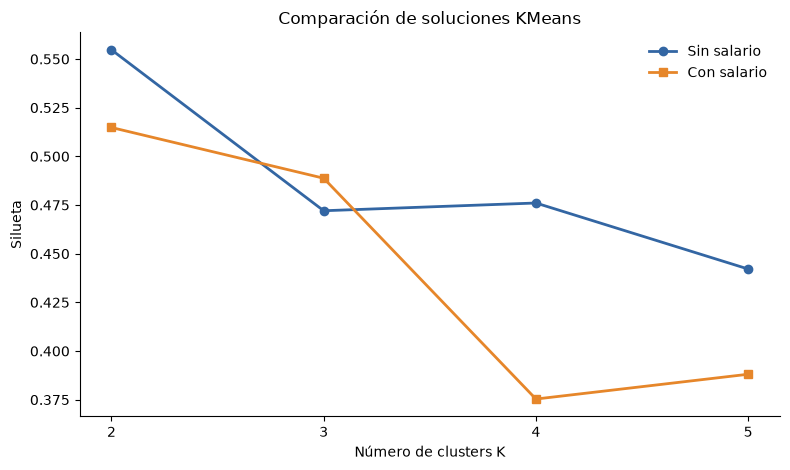

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for spec_name, marker, color in [("Sin salario", "o", COLORS["blue"]), ("Con salario", "s", COLORS["orange"])]:
    subset = cluster_evaluation[cluster_evaluation["especificacion"] == spec_name]
    ax.plot(subset["k"], subset["silueta"], marker=marker, color=color, linewidth=2.0, label=spec_name)
ax.set_xticks([2, 3, 4, 5])
ax.set_xlabel("Número de clusters K")
ax.set_ylabel("Silueta")
ax.set_title("Comparación de soluciones KMeans")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "kmeans_silueta.png", dpi=180, bbox_inches="tight")
plt.show()

### Selección de K y efecto del salario

La mayor silueta corresponde a $K = 2$ sin salario (0.5547), con un cluster mínimo de 27.51%. Al incluir salario, la mejor alternativa también es $K = 2$, pero la silueta baja a 0.5148. Con cuatro y cinco clusters, la especificación con salario forma grupos menores al 5%, señal de que los valores altos empiezan a aislar observaciones poco frecuentes. Por este motivo se selecciona $K = 2$ con edad, antigüedad y horas. El salario queda como variable externa para describir las diferencias entre perfiles, sin dirigir la formación de los grupos.

In [18]:
best_model, best_scaler, best_assembler, best_scaled_col, best_predictions = cluster_objects[best_key]
best_predictions = best_predictions.withColumnRenamed("prediction", "cluster").persist(StorageLevel.MEMORY_AND_DISK)

cluster_profiles_spark = (
    best_predictions.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.avg("edad").alias("edad_media"),
        F.expr("percentile_approx(edad, 0.5, 10000)").alias("edad_mediana"),
        F.avg("antiguedad").alias("antiguedad_media"),
        F.expr("percentile_approx(antiguedad, 0.5, 10000)").alias("antiguedad_mediana"),
        F.avg("horas_semanales").alias("horas_media"),
        F.expr("percentile_approx(horas_semanales, 0.5, 10000)").alias("horas_mediana"),
        F.avg("salario_mensual").alias("salario_medio"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano"),
    )
    .withColumn("porcentaje", 100 * F.col("n") / F.lit(total_cluster_rows))
    .orderBy("cluster")
)
cluster_profiles = cluster_profiles_spark.toPandas()

def modal_category(df, column):
    counts = df.groupBy("cluster", column).count()
    w = Window.partitionBy("cluster").orderBy(F.desc("count"), F.asc(column))
    return (
        counts.withColumn("rank", F.row_number().over(w))
        .filter(F.col("rank") == 1)
        .select("cluster", F.col(column).alias(f"{column}_modal"))
        .toPandas()
    )

for category in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    cluster_profiles = cluster_profiles.merge(modal_category(best_predictions, category), on="cluster", how="left")

overall = prepared_2025.agg(
    F.avg("edad").alias("edad"),
    F.avg("antiguedad").alias("antiguedad"),
    F.avg("horas_semanales").alias("horas"),
).first().asDict()

def describe_cluster(row):
    parts = []
    if row["edad_media"] < overall["edad"] - 4:
        parts.append("más jóvenes")
    elif row["edad_media"] > overall["edad"] + 4:
        parts.append("de mayor edad")
    else:
        parts.append("de edad intermedia")
    if row["antiguedad_media"] < overall["antiguedad"] - 2:
        parts.append("con poca antigüedad")
    elif row["antiguedad_media"] > overall["antiguedad"] + 2:
        parts.append("con mayor antigüedad")
    else:
        parts.append("con antigüedad intermedia")
    if row["horas_media"] < overall["horas"] - 5:
        parts.append("y jornadas más cortas")
    elif row["horas_media"] > overall["horas"] + 5:
        parts.append("y jornadas más largas")
    else:
        parts.append("y jornadas cercanas al promedio")
    return ", ".join(parts[:2]) + " " + parts[2]

cluster_profiles["descripcion"] = cluster_profiles.apply(describe_cluster, axis=1)
display(cluster_profiles.style.format({
    "n": "{:,.0f}", "porcentaje": "{:.1f}%", "edad_media": "{:.1f}",
    "edad_mediana": "{:.1f}", "antiguedad_media": "{:.1f}", "antiguedad_mediana": "{:.1f}",
    "horas_media": "{:.1f}", "horas_mediana": "{:.1f}",
    "salario_medio": "Q{:,.0f}", "salario_mediano": "Q{:,.0f}",
}))

,cluster,n,edad_media,edad_mediana,antiguedad_media,antiguedad_mediana,horas_media,horas_mediana,salario_medio,salario_mediano,porcentaje,nivel_educativo_modal,categoria_ocupacional_modal,dominio_modal,descripcion
0,0,"14,586",51.3,51.0,13.8,13.0,41.3,40.0,"Q4,070","Q3,466",27.5%,Primaria,Empleado de empresa privada,Urbano metropolitano,"de mayor edad, con mayor antigüedad y jornadas más cortas"
1,1,"38,439",29.1,28.0,2.4,1.3,48.2,46.0,"Q3,176","Q3,000",72.5%,Diversificado,Empleado de empresa privada,Urbano metropolitano,"más jóvenes, con poca antigüedad y jornadas cercanas al promedio"


### Perfiles obtenidos

- **Cluster 0, mayor edad y antigüedad:** contiene 14,586 registros (27.51%). La edad media es 51.3 años, la antigüedad media 13.8 años y la jornada media 41.3 horas. El salario mediano es Q3,466. El nivel educativo modal es primaria.
- **Cluster 1, menor edad y antigüedad:** contiene 38,439 registros (72.49%). La edad media es 29.1 años, la antigüedad media 2.4 años y la jornada media 48.2 horas. El salario mediano es Q3,000. El nivel educativo modal es diversificado.

En ambos clusters predominan el empleo en empresa privada y el dominio urbano metropolitano. Estas categorías modales no significan que todos los integrantes compartan esa condición. La diferencia principal entre perfiles está en la edad y la antigüedad, acompañada por una jornada media algo más larga en el grupo joven.

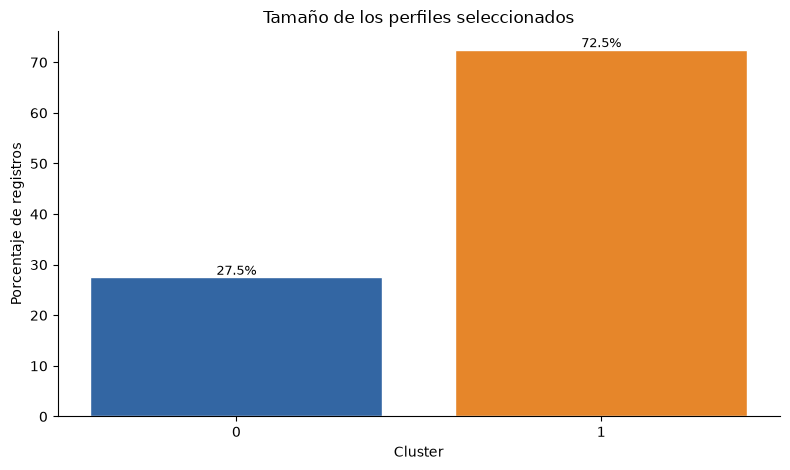

Modelo guardado en: C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 7\Lab-7-Data-Science\data\processed\modelo_kmeans_avance


In [19]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_profiles = cluster_profiles.sort_values("cluster")
ax.bar(plot_profiles["cluster"].astype(str), plot_profiles["porcentaje"], color=[COLORS["blue"], COLORS["orange"]], edgecolor="white")
ax.set_xlabel("Cluster")
ax.set_ylabel("Porcentaje de registros")
ax.set_title("Tamaño de los perfiles seleccionados")
ax.spines[["top", "right"]].set_visible(False)
for i, value in enumerate(plot_profiles["porcentaje"]):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "kmeans_tamano_clusters.png", dpi=180, bbox_inches="tight")
plt.show()

model_path = str((PROCESSED_DIR / "modelo_kmeans_avance").resolve())
best_model.write().overwrite().save(model_path)
print("Modelo guardado en:", model_path)

## 6. Respuestas metodológicas del avance

- **Unión del cuarto trimestre:** no se apila por posición porque contiene 302 columnas frente a 270 en los otros archivos y el orden no es idéntico. `unionByName` mantiene el significado de cada variable.
- **Ausencia y no respuesta:** una ausencia por salto del cuestionario indica que la pregunta no aplicaba; una no respuesta corresponde a una pregunta aplicable sin valor registrado. El tratamiento requiere revisar las variables de control y la boleta.
- **Observaciones longitudinales:** la misma persona en dos trimestres representa dos mediciones en momentos diferentes. Eliminar una de ellas perdería información temporal.
- **Alcance de los conteos:** la base analítica es una submuestra filtrada y las métricas son no ponderadas. El factor de expansión se conserva, pero no se usa en este avance.
- **Salarios extremos:** se mantienen en las estadísticas y en la evaluación de la especificación de clustering. Su presencia explica parte de la diferencia entre la media y la mediana y puede afectar KMeans cuando el salario se incluye.
- **Interpretación:** los perfiles y asociaciones describen patrones en los registros analizados. No establecen relaciones causales ni indican cuánto debería ganar una persona.